In [1]:
import pandas as pd

df = pd.read_json('/home/bartosz-linux/study/bcmp-networks/logs/14kR7_n9Fy.jsonl', lines=True)


In [2]:
df.head()

,source,ts,action,request_id,type,new_type,dest_id
0,WS 1,00:00:871,received,0,type3,NaN,NaN
1,WS 1,00:00:871,queued,0,type3,NaN,NaN
2,GN 2,00:00:871,generated,0,type3,NaN,NaN
3,WS 1,00:00:871,started,0,type3,NaN,NaN
4,WS 1,00:01:061,received,1,type3,NaN,NaN


In [39]:
# Convert the timestamp 'ts' column to a standard datetime.timedelta format for easy time calculations
import numpy as np
import datetime as dt
def avg_requests_per_class(df):
# Convert 'ts' to timedelta
    def parse_timestamp(ts):
        try:
            minutes, seconds, milliseconds = map(int, ts.split(':'))
            return dt.timedelta(minutes=minutes, seconds=seconds, milliseconds=milliseconds)
        except:
            return np.nan

    df['ts'] = df['ts'].apply(parse_timestamp)

    # Filter relevant rows for each calculation by actions
    # Extracting queueing and processing stages
    queued_df = df[df['action'] == 'queued']
    started_df = df[df['action'] == 'started']
    processed_df = df[df['action'] == 'processed']

    # Calculating average number of requests by class and server
    avg_requests_per_class_server = df.groupby(['source', 'new_type'])['request_id'].nunique().groupby(level=0).mean()


    # Combining results into a single DataFrame for presentation
    results_df = pd.DataFrame({
        'avg_requests_per_class': avg_requests_per_class_server,
    }).reset_index()


    return results_df

avg_requests_per_class(df)
    

,source,avg_requests_per_class
0,WS 1,54.333333
1,WS 2,191.000000
2,WS 3,83.000000
3,WS 4,41.000000
4,WS 5,64.000000


Processing for source: WS 1


/tmp/ipykernel_36071/2563250815.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['ts'] = pd.to_timedelta(data_subset['ts'])


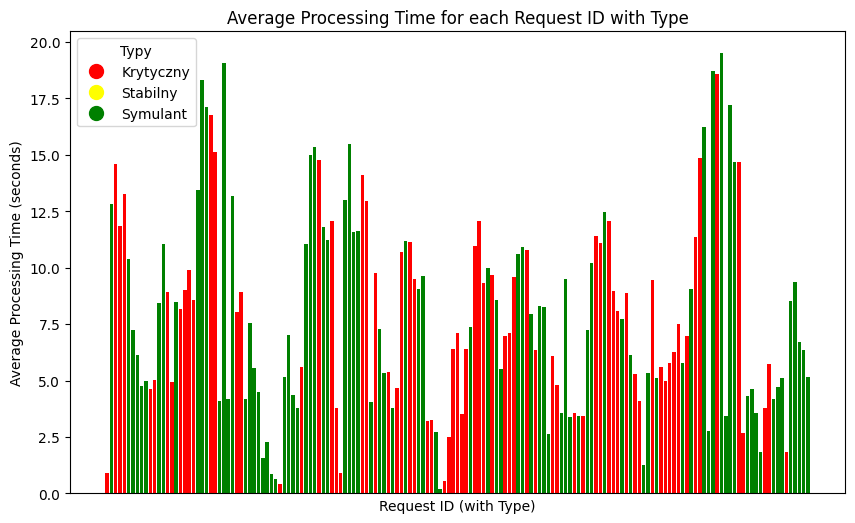

Processing for source: WS 2


/tmp/ipykernel_36071/2563250815.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['ts'] = pd.to_timedelta(data_subset['ts'])


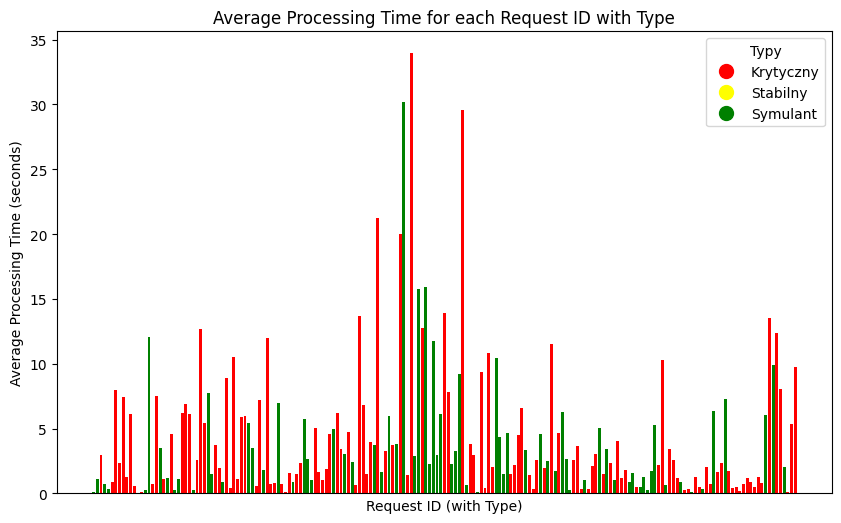

Processing for source: WS 5


/tmp/ipykernel_36071/2563250815.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['ts'] = pd.to_timedelta(data_subset['ts'])


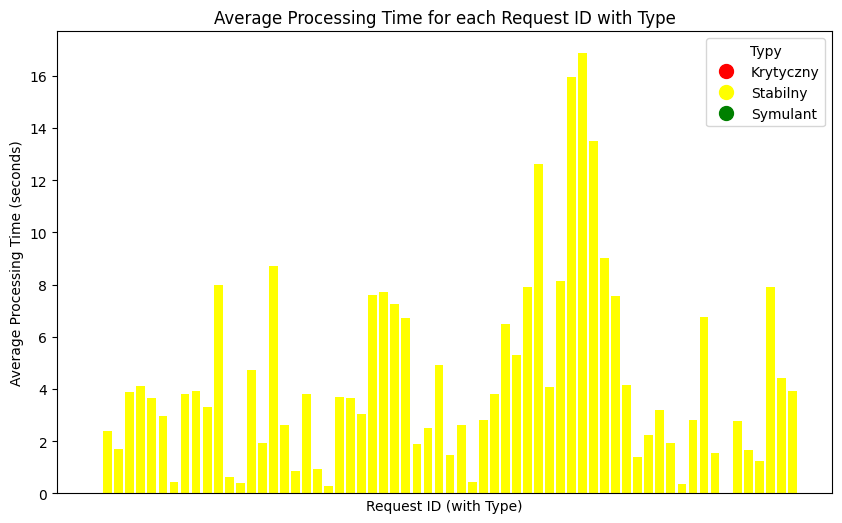

Processing for source: WS 4


/tmp/ipykernel_36071/2563250815.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['ts'] = pd.to_timedelta(data_subset['ts'])


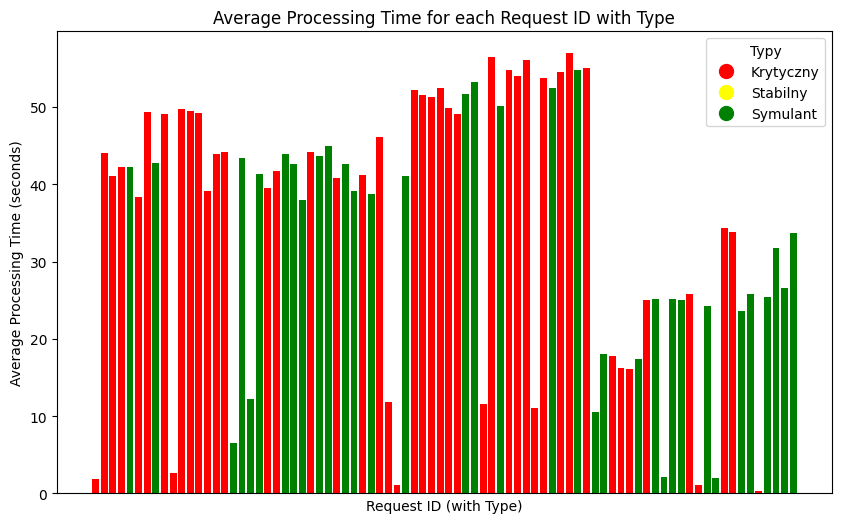

Processing for source: WS 3


/tmp/ipykernel_36071/2563250815.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_subset['ts'] = pd.to_timedelta(data_subset['ts'])


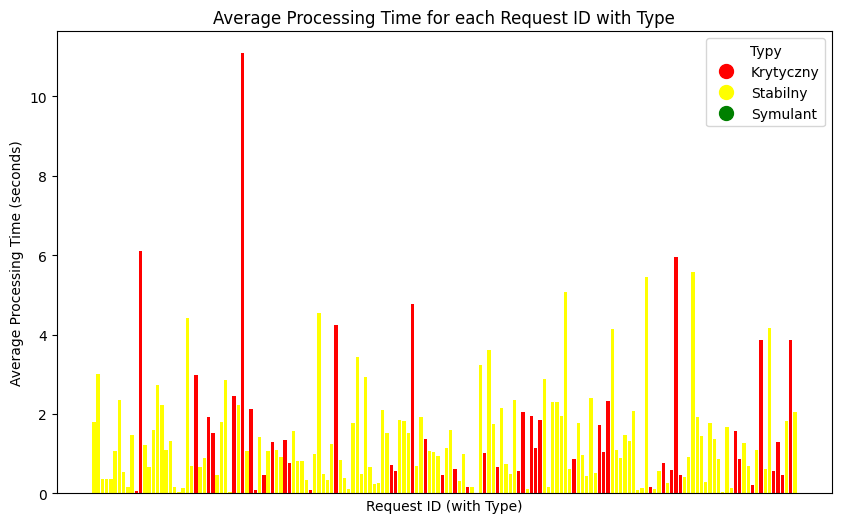

In [37]:

import matplotlib.pyplot as plt

def plot_avg_time_request_server_with_type(data_subset):
    data_subset['ts'] = pd.to_timedelta(data_subset['ts'])
    data_subset = data_subset.sort_values(by=['request_id', 'ts'])

    processing_intervals = []
    new_request_id = None

    type_color_mapping = {
        "type1": "green",
        "type2": "yellow",
        "type3": "red"
    }

    for request_id, group in data_subset.groupby('request_id'):
        group = group.reset_index(drop=True)  # Reset index for clean iteration
        
        # Track the starting type
        last_type = None
        for i, row in group.iterrows():
            # Update the request_id to include type if it changes
            if row['action'] == 'received' or (last_type and row.get('new_type') != last_type):
                current_type = row.get('new_type') if row.get('new_type') else 'initial'
                new_request_id = f"{request_id}_{i}_{current_type}"
                
            # Capture the start time and update type
            if row['action'] == 'received':
                start_time = row['ts']
                # last_type = row.get('new_type', 'initial')
                last_type = row['type']
            
            elif row['action'] in ['forwarded', 'rejected']:
                end_time = row['ts']
                processing_time = (end_time - start_time).total_seconds()

                # print(f"Request ID: {new_request_id}, Processing Time: {processing_time}, Type: {last_type}")
                if processing_time > 0:
                    processing_intervals.append({
                        'request_id': new_request_id, 
                        'processing_time': processing_time, 
                        'type': last_type
                    })
                    

                last_type = row.get('new_type', 'initial')

    # Create a DataFrame from the collected intervals
    processing_intervals_df = pd.DataFrame(processing_intervals)
    processing_intervals_df['type'] = processing_intervals_df['type'].map(type_color_mapping)
    # print(processing_intervals_df)


    # Calculate average processing time and include the type column in the output
    if not processing_intervals_df.empty:
        average_processing_time_df = processing_intervals_df.groupby(['request_id', 'type'])['processing_time'].mean().reset_index()
        
        # Plotting
        plt.figure(figsize=(10, 6))
        plt.bar(average_processing_time_df['request_id'], average_processing_time_df['processing_time'], color=average_processing_time_df['type'])
        plt.xlabel('Request ID (with Type)')
        plt.ylabel('Average Processing Time (seconds)')
        plt.title('Average Processing Time for each Request ID with Type')
        legend_labels = {
    "red": "Krytyczny",
    "yellow": "Stabilny",
    "green": "Symulant"
}
        # Create legend handles
        handles = [plt.Line2D([0], [0], marker='o', color=color, label=label, markersize=10, linestyle='None')
                for color, label in legend_labels.items()]
        plt.legend(handles=handles, title="Typy")
        plt.xticks([], [])  
        plt.show()
    else:
        print(f"No valid processing times for source subset.")
    
    
for source in df['source'].unique():
    if "WS" in source:
        data_subset = df[df['source'] == source]
        print(f"Processing for source: {source}")
        plot_avg_time_request_server_with_type(data_subset)